#### 01 — Data Discovery

##### Objective

The first stage of the project is to understand the real-world customer feedback dataset before making any product assumptions or applying AI.

I am using the Consumer Financial Protection Bureau (CFPB) Consumer Complaint Database and focusing initially on credit card complaints that contain a consumer narrative.

The main questions at this stage are:

- What does the dataset contain?
- How large is the available complaint population?
- What does the customer feedback look like?
- How complete and usable is the data?
- What patterns are visible before using AI?

The goal is to understand the evidence first and use it to guide the next stage of the product analysis.

##### 1. Data Source

The data comes from the Consumer Financial Protection Bureau (CFPB) Consumer Complaint Database.

The database contains publicly available complaints submitted by consumers about financial products and services.

For this project, the initial scope is:

**Product:** Credit card

**Feedback requirement:** Consumer complaint narrative is available

The CFPB provides an API that allows the complaint database to be queried programmatically.

In [44]:
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt
import seaborn as sns

from io import StringIO
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 200)
pd.set_option("display.max_rows", 100)

##### 2. Project Paths

I will keep raw data separate from processed data.

This allows the original dataset to remain unchanged while cleaned and transformed versions are created separately.

In [45]:
PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data"
RAW_DATA_DIR = DATA_DIR / "raw"
PROCESSED_DATA_DIR = DATA_DIR / "processed"

RAW_DATA_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Raw data directory:", RAW_DATA_DIR)
print("Processed data directory:", PROCESSED_DATA_DIR)

Project root: c:\Users\uttam\Desktop\project 2
Raw data directory: c:\Users\uttam\Desktop\project 2\data\raw
Processed data directory: c:\Users\uttam\Desktop\project 2\data\processed


##### 3. CFPB API

The CFPB complaint search API will be used to retrieve the data.

I am using the API rather than manually downloading a dataset so that the data collection process can be reproduced later.

In [46]:
API_URL = "https://www.consumerfinance.gov/data-research/consumer-complaints/search/api/v1/"

print(API_URL)

https://www.consumerfinance.gov/data-research/consumer-complaints/search/api/v1/


##### 4. Confirming the API Connection

Before collecting the working dataset, I will make a small request to confirm that the API is accessible and that the required filters work.

In [47]:
params = {
    "product": "Credit card",
    "has_narrative": "true",
    "size": 5
}

response = requests.get(API_URL, params=params, timeout=60)

print("Status code:", response.status_code)
print("Content type:", response.headers.get("content-type"))

Status code: 200
Content type: application/json


#### API Check

The API returned a successful response for the selected product and narrative filters.

The response will now be inspected before collecting the larger working dataset.

In [48]:
data = response.json()

print("Top-level response fields:")
print(data.keys())

print("\nComplaint result fields:")
print(data["hits"].keys())

Top-level response fields:
dict_keys(['took', 'timed_out', '_shards', 'hits', 'aggregations', '_meta'])

Complaint result fields:
dict_keys(['total', 'max_score', 'hits'])


##### 5. Understanding a Single Complaint

Before loading thousands of records, I am inspecting one record to understand the structure returned by the API.

In [49]:
first_complaint = data["hits"]["hits"][0]["_source"]

first_complaint

{'product': 'Credit card',
 'complaint_what_happened': 'Chae bank called me about a fraudulent case application. They gave me a case number XXXX, tranferred me CFPB. During the call, long silent when agent said is looking at the report, then cut off. No call back was done.',
 'date_sent_to_company': '2024-09-03T22:18:48.000Z',
 'issue': 'Getting a credit card',
 'sub_product': 'General-purpose credit card or charge card',
 'zip_code': '01923',
 'tags': None,
 'has_narrative': True,
 'complaint_id': '9999983',
 'timely': 'Yes',
 'company_response': 'Closed with explanation',
 'submitted_via': 'Web',
 'company': 'JPMORGAN CHASE & CO.',
 'date_received': '2024-09-03T22:07:34.000Z',
 'state': 'MA',
 'company_public_response': None,
 'sub_issue': 'Card opened without my consent or knowledge'}

The API response contains both structured information about the complaint and the consumer's written description of what happened.

The consumer narrative is particularly important for this project because it provides the unstructured customer feedback that will later be analyzed for recurring problems and themes.

##### 6. Measuring the Available Complaint Population

Before deciding how much data to analyze, I want to understand the size of the available population matching the project scope.

The query below counts credit card complaints that contain a consumer narrative.

In [50]:
params = {
    "product": "Credit card",
    "has_narrative": "true",
    "size": 0
}

response = requests.get(API_URL, params=params, timeout=60)

print("Status code:", response.status_code)

population_data = response.json()

total_complaints = population_data["hits"]["total"]["value"]

print("Matching complaints:", total_complaints)

Status code: 200
Matching complaints: 127919


##### Dataset Scale Finding

The API returns a large population of credit card complaints containing consumer narratives.

The total count is recorded from the API response at the time of analysis rather than treated as a permanent number because the CFPB complaint database can change over time.

This confirms that the available dataset is large enough to support meaningful customer-feedback analysis.

##### 7. Initial Working Dataset

I will initially work with 10,000 complaints.

The purpose of this dataset is exploratory analysis and development of the feedback-analysis workflow. It is not treated as a statistically representative sample of all consumers.

The raw dataset will be preserved before any cleaning or transformation.

In [51]:
params = {
    "product": "Credit card",
    "has_narrative": "true",
    "size": 10000
}

response = requests.get(API_URL, params=params, timeout=120)

print("Status code:", response.status_code)

data = response.json()

records = [
    hit["_source"]
    for hit in data["hits"]["hits"]
]

df_raw = pd.DataFrame(records)

print("Rows returned:", len(df_raw))
print("Columns:", len(df_raw.columns))

Status code: 200
Rows returned: 10000
Columns: 17


In [52]:
raw_file = RAW_DATA_DIR / "cfpb_credit_card_complaints.csv"

df_raw.to_csv(raw_file, index=False)

print("Raw dataset saved to:")
print(raw_file)

Raw dataset saved to:
c:\Users\uttam\Desktop\project 2\data\raw\cfpb_credit_card_complaints.csv


In [53]:
df = pd.read_csv(raw_file)

print("Dataset shape:", df.shape)

Dataset shape: (10000, 17)


#### 8. Dataset Structure

The working dataset contains the records retrieved from the CFPB API.

I will first examine the structure of the data without modifying it.

In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   product                  10000 non-null  object
 1   complaint_what_happened  10000 non-null  object
 2   date_sent_to_company     10000 non-null  object
 3   issue                    10000 non-null  object
 4   sub_product              10000 non-null  object
 5   zip_code                 10000 non-null  object
 6   tags                     2105 non-null   object
 7   has_narrative            10000 non-null  bool  
 8   complaint_id             10000 non-null  int64 
 9   timely                   10000 non-null  object
 10  company_response         10000 non-null  object
 11  submitted_via            10000 non-null  object
 12  company                  10000 non-null  object
 13  date_received            10000 non-null  object
 14  state                    9959 non-null 

In [55]:
df.head()

,product,complaint_what_happened,date_sent_to_company,issue,sub_product,zip_code,tags,has_narrative,complaint_id,timely,company_response,submitted_via,company,date_received,state,company_public_response,sub_issue
0,Credit card,"Chae bank called me about a fraudulent case application. They gave me a case number XXXX, tranferred me CFPB. During the call, long silent when agent said is looking at the report, then cut off. N...",2024-09-03T22:18:48.000Z,Getting a credit card,General-purpose credit card or charge card,01923,NaN,True,9999983,Yes,Closed with explanation,Web,JPMORGAN CHASE & CO.,2024-09-03T22:07:34.000Z,MA,NaN,Card opened without my consent or knowledge
1,Credit card,"I, XXXX XXXX, on this XX/XX/XXXX, submit this CFPB complaint against Capital One Auto Finance. I allege that on or about XX/XX/XXXX, Capital One Auto Finance discriminated against me as defined by...",2024-09-03T22:53:59.000Z,Getting a credit card,General-purpose credit card or charge card,33150,NaN,True,9999323,Yes,Closed with explanation,Web,CAPITAL ONE FINANCIAL CORPORATION,2024-09-03T22:25:57.000Z,FL,NaN,Application denied
2,Credit card,"I made a purchase using Afterpay with XXXX through the afterpay app. My delivery was supposed to be scheduled within XXXX hours of placing the order. When I went into the app to check on my order,...",2024-09-03T23:43:26.000Z,Problem with a purchase shown on your statement,General-purpose credit card or charge card,73064,NaN,True,9999322,Yes,Closed with monetary relief,Web,"Block, Inc.",2024-09-03T23:33:19.000Z,OK,NaN,Credit card company isn't resolving a dispute about a purchase on your statement
3,Credit card,I opened a Chase Freedom Unlimited Card in XXXX of 2024 as the promotion on their website says Earn a {$200.00} bonus after you spend {$500.00} on purchases in the first 3 months from account open...,2024-09-03T23:12:05.000Z,"Advertising and marketing, including promotional offers",General-purpose credit card or charge card,90745,NaN,True,9999139,Yes,Closed with explanation,Web,JPMORGAN CHASE & CO.,2024-09-03T22:57:16.000Z,CA,NaN,Didn't receive advertised or promotional terms
4,Credit card,XXXX XXXX store credit card company XXXX XXXX XXXX XXXX XXXX for assistance XX/XX/year>. Was misled that the credit protection being offered at the time was credit protection program i had been pa...,2024-09-03T23:40:37.000Z,"Other features, terms, or problems",Store credit card,33311,NaN,True,9999003,Yes,Closed with explanation,Web,"Bread Financial Holdings, Inc.",2024-09-03T22:50:01.000Z,FL,NaN,Add-on products and services


In [56]:
df.columns.tolist()

['product',
 'complaint_what_happened',
 'date_sent_to_company',
 'issue',
 'sub_product',
 'zip_code',
 'tags',
 'has_narrative',
 'complaint_id',
 'timely',
 'company_response',
 'submitted_via',
 'company',
 'date_received',
 'state',
 'company_public_response',
 'sub_issue']

##### Initial Structure Observation

The dataset contains structured complaint information such as product, issue, sub-issue, company, dates, submission channel and response information.

It also contains the consumer complaint narrative:

`complaint_what_happened`

This field will be the main source of unstructured customer feedback for the later analysis.

##### 9. Data Quality Check

Before analyzing customer problems, I need to understand whether the dataset contains missing values or duplicate records.

At this stage I will measure the problem rather than immediately removing incomplete records.

In [57]:
missing = df.isna().sum()

missing[missing > 0].sort_values(ascending=False)

tags                       7895
company_public_response    5237
state                        41
sub_issue                     9
dtype: int64

In [58]:
duplicate_ids = df["complaint_id"].duplicated().sum()

print("Duplicate complaint IDs:", duplicate_ids)

Duplicate complaint IDs: 0


In [59]:
print("Narrative flag distribution:")
print(df["has_narrative"].value_counts(dropna=False))

print(
    "\nEmpty narratives:",
    df["complaint_what_happened"]
    .fillna("")
    .str.strip()
    .eq("")
    .sum()
)

Narrative flag distribution:
has_narrative
True    10000
Name: count, dtype: int64

Empty narratives: 0


##### Data Quality Finding

The 10,000-record working dataset contains no duplicate complaint IDs.

All records have a consumer narrative and the narrative field contains usable text.

Missing values are concentrated in `tags`, `company_public_response`, `state`, and `sub_issue`.

The missing values do not automatically justify removing those records. The relevance of each field will be considered before deciding whether it is needed for the analysis.

##### 10. Complaint Categories

The CFPB already provides structured issue and sub-issue classifications.

I will examine these categories before applying any AI method.

This provides a baseline understanding of the problems represented in the dataset and allows the later AI analysis to be compared with the existing classification system.

In [61]:
issue_counts = df["issue"].value_counts()

issue_counts

issue
Problem with a purchase shown on your statement                    2436
Getting a credit card                                              1277
Fees or interest                                                   1220
Other features, terms, or problems                                 1164
Closing your account                                                764
Problem with a company's investigation into an existing problem     745
Problem when making payments                                        628
Incorrect information on your report                                561
Advertising and marketing, including promotional offers             474
Trouble using your card                                             436
Struggling to pay your bill                                         143
Improper use of your report                                         107
Credit monitoring or identity theft protection services              30
Problem with fraud alerts or security freezes             

In [62]:
sub_issue_counts = df["sub_issue"].value_counts()

sub_issue_counts.head(20)

sub_issue
Credit card company isn't resolving a dispute about a purchase on your statement    1740
Card opened without my consent or knowledge                                          829
Problem with fees                                                                    805
Card was charged for something you did not purchase with the card                    623
Other problem                                                                        578
Problem during payment process                                                       548
Company closed your account                                                          534
Their investigation did not fix an error on your report                              393
Can't use card to make purchases                                                     313
Didn't receive advertised or promotional terms                                       309
Application denied                                                                   301
Was not not

##### Initial Category Findings

The complaints are concentrated in a relatively small number of issue categories.

The largest category in the working dataset is **"Problem with a purchase shown on your statement"**, followed by **"Getting a credit card"**, **"Fees or interest"**, and **"Other features, terms, or problems."**

At the sub-issue level, the largest group is **"Credit card company isn't resolving a dispute about a purchase on your statement"**, followed by **"Card opened without my consent or knowledge"** and **"Problem with fees."**

These categories provide a useful starting point, but I will not treat the most frequent category as the final product problem. The next step is to examine the actual customer narratives to understand what customers are describing within these categories.

##### 11. Company Distribution

Company information can provide useful context about where complaints are concentrated.

I will use it as supporting context rather than assuming that a company with more complaints necessarily has worse product performance, since complaint volume can also be influenced by company size and customer base.

In [63]:
print("Number of companies:", df["company"].nunique())

df["company"].value_counts().head(15)

Number of companies: 205


company
CITIBANK, N.A.                            1172
CAPITAL ONE FINANCIAL CORPORATION         1086
SYNCHRONY FINANCIAL                       1012
JPMORGAN CHASE & CO.                       899
AMERICAN EXPRESS COMPANY                   605
BANK OF AMERICA, NATIONAL ASSOCIATION      535
Bread Financial Holdings, Inc.             445
WELLS FARGO & COMPANY                      362
DISCOVER BANK                              330
TRANSUNION INTERMEDIATE HOLDINGS, INC.     324
GOLDMAN SACHS BANK USA                     320
Experian Information Solutions Inc.        309
BARCLAYS BANK DELAWARE                     302
EQUIFAX, INC.                              294
U.S. BANCORP                               191
Name: count, dtype: int64

##### 12. Submission Channel

The submission channel shows how customers entered the complaint process.

This is not a primary product-problem variable, but it provides useful context about the source of the feedback.

In [64]:
df["submitted_via"].value_counts()

submitted_via
Web    10000
Name: count, dtype: int64

##### 13. Time Coverage

The date received field is currently stored as text, so I will convert it to a datetime value for analysis.

This transformation will be applied to the working DataFrame, not the raw CSV.

In [65]:
df["date_received"] = pd.to_datetime(df["date_received"])

print("Earliest complaint:", df["date_received"].min())
print("Latest complaint:", df["date_received"].max())

Earliest complaint: 2024-05-13 00:10:29+00:00
Latest complaint: 2024-09-04 07:12:29+00:00


In [66]:
df["date_received"].dt.to_period("M").value_counts().sort_index()

C:\Users\uttam\AppData\Local\Temp\ipykernel_22284\3362559034.py:1: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df["date_received"].dt.to_period("M").value_counts().sort_index()


date_received
2024-05    2084
2024-06    2483
2024-07    2541
2024-08    2769
2024-09     123
Freq: M, Name: count, dtype: int64

##### Time Coverage Finding

The initial 10,000-record API response covers a relatively narrow period compared with the full available complaint population.

Therefore, I will not use this initial dataset to make broad historical trend claims.

The dataset is currently being treated as a working sample for customer-feedback exploration. A more deliberate sampling approach can be considered if time-based analysis becomes important to the product decision.

##### 14. Customer Narrative Exploration

The structured issue categories tell me how the CFPB classified each complaint, but they do not necessarily explain the customer's complete experience.

I will therefore inspect the complaint narratives directly before deciding what customer problems are worth investigating further.

At this stage, I am looking for recurring patterns in what customers experienced, what they expected, and where their experience broke down.

In [67]:
pd.set_option("display.max_colwidth", 500)

sample_narratives = df[
    ["complaint_id", "issue", "sub_issue", "complaint_what_happened"]
].sample(10, random_state=42)

sample_narratives

,complaint_id,issue,sub_issue,complaint_what_happened
6252,9311191,Getting a credit card,Application denied,"From XXXX XX/XX/year> to present I called the Chase reconsideration phone line approximately XXXX times often speaking to multiple customer service XXXX. These XXXX reportedly attempted to process my application. They asked me numerous security related questions and I cooperated fully. They sent me internal notices in my chase app on XXXX XXXX, XXXX XXXX, and XXXX XXXX stating their belief I was a victim of identity theft and someone was trying to seek credit in my name. I called Chase each ..."
4684,9475068,Problem with a purchase shown on your statement,Credit card company isn't resolving a dispute about a purchase on your statement,"In XXXX of XXXX, I took out a loan of {$7900.00} for the aforementioned installation. The loan agreement specified a XXXX XXXX period. To ensure timely payment, I diligently set up auto payments, confident that the entire loan amount would be paid off within the agreed period. \n\nHowever, to my dismay, I discovered that after only XXXX months, Citi Bank began charging me interest without prior notification. \n\nUpon contacting Home Depot, I was assured that the issue would be promptly addre..."
1731,9797881,"Other features, terms, or problems",Problem with customer service,"On XX/XX/year>, I was charged a {$29.00} late fee to my account ( which was late ). On Monday XX/XX/year>, at XXXX, I received the first call from Prosper LLC . I was at work and did not answer, but Prosper LLC left a message regarding the lateness of the account which was 5 days past due, and I had already been charged the late fee of {$29.00}. Then they called me again at at XXXX that same day, I did not speak with them. On Tuesday XX/XX/year>, I was called at XXXX, XXXX, and XXXX XXXX, an..."
4742,9468570,Getting a credit card,Card opened without my consent or knowledge,"This account represents a clear breach of contract and is fraudulent in nature. The bank failed to provide me with essential information regarding this fraudulent account, which is a direct violation of my rights as a consumer. Therefore, I urgently request the Consumer Financial Protection Bureau ( CFPB ) to handle this matter directly, as the bank 's actions have resulted in significant harm to my financial well-being. The account is XXXX XXXX XXXX # XXXX"
4521,9492568,Problem with a purchase shown on your statement,Credit card company isn't resolving a dispute about a purchase on your statement,"About a month ago, I filed a dispute with my credit card company Bank of America for charges from XXXX that I did not authorize or approve of. There were XXXX charges of {$500.00} each. My claim was denied and the letter I received stated it was denied because the merchant provided proof that I received the product or service that I paid for. There are XXXXwo issues with that. One, I never received any product or service from the merchant because again, I did not use my card with them and di..."
6340,9303791,"Other features, terms, or problems",Privacy issues,They have violated my right to privacy per the privacy act of 1974. I choose to opt out from sharing any of my information. \n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\nin
576,9928541,Fees or interest,Problem with fees,Charged late fee after signing up for autopay with autopay not working. Late fee is above the maximum limit set by Cfpb
5202,9414931,Problem with a purchase shown on your statement,Card was charged for something you did not purchase with the card,I have direct express card through Comerica bank direct express will show the address of the purchase but not the name of the company so I have to call direct express and wait over half hour to get the name of the company that charged my card completely wasting my time when all direct express has to do is show the n

In [68]:
for i, row in sample_narratives.iterrows():
    print("=" * 100)
    print("Complaint ID:", row["complaint_id"])
    print("Issue:", row["issue"])
    print("Sub-issue:", row["sub_issue"])
    print("\nCustomer narrative:")
    print(row["complaint_what_happened"])
    print()

Complaint ID: 9311191
Issue: Getting a credit card
Sub-issue: Application denied

Customer narrative:
From XXXX XX/XX/year> to present I called the Chase reconsideration phone line approximately XXXX times often speaking to multiple customer service XXXX. These XXXX reportedly attempted to process my application. They asked me numerous security related questions and I cooperated fully. They sent me internal notices in my chase app on XXXX XXXX, XXXX XXXX, and XXXX XXXX stating their belief I was a victim of identity theft and someone was trying to seek credit in my name. I called Chase each time and clarified it was I applying for the Chase Ink Cash card. They requested identifying documents and on or about XXXX XXXX I submitted a photocopy of my XXXX Passport, XXXX XXXX ID Drivers license and utility documents. I called to confirm receipt and acceptance. This was all confirmed by Chase representative on XXXX and XXXX XX/XX/year>. I was even lied to by Chase staff who informed me I was

#### 15. Initial Data Discovery Findings

The initial exploration shows that the CFPB complaint dataset contains both structured classifications and unstructured customer narratives.

The structured fields provide a hierarchy of product, issue, and sub-issue categories. The customer narrative provides additional detail about the customer's actual experience.

In the 10,000-record working dataset:

- Complaint IDs are unique.
- All records contain a consumer narrative.
- Most fields required for the initial analysis are populated.
- Missing values are mainly found in tags, company public response, state, and sub-issue.
- Complaints are concentrated in a relatively small number of issue and sub-issue categories.
- The dataset contains complaints from many different companies.
- The initial API response covers a limited time period, so it will not be treated as a representation of the entire historical complaint population.

The existing CFPB categories provide a useful baseline, but the customer narratives may contain additional patterns that are not visible from the structured categories alone.

The next analysis will therefore focus on understanding the distribution and characteristics of the customer narratives before introducing any AI technique.



##### 16. Customer Narrative Characteristics

Before applying text-analysis techniques, I will examine some basic characteristics of the customer narratives.

This will help determine whether the narratives contain enough information for deeper analysis and whether there are unusually short or long records that may need separate treatment.

In [69]:
df["narrative_length"] = (
    df["complaint_what_happened"]
    .fillna("")
    .str.split()
    .str.len()
)

df["narrative_length"].describe()

count    10000.000000
mean       206.990000
std        234.026228
min          4.000000
25%         71.000000
50%        147.000000
75%        264.000000
max       4590.000000
Name: narrative_length, dtype: float64

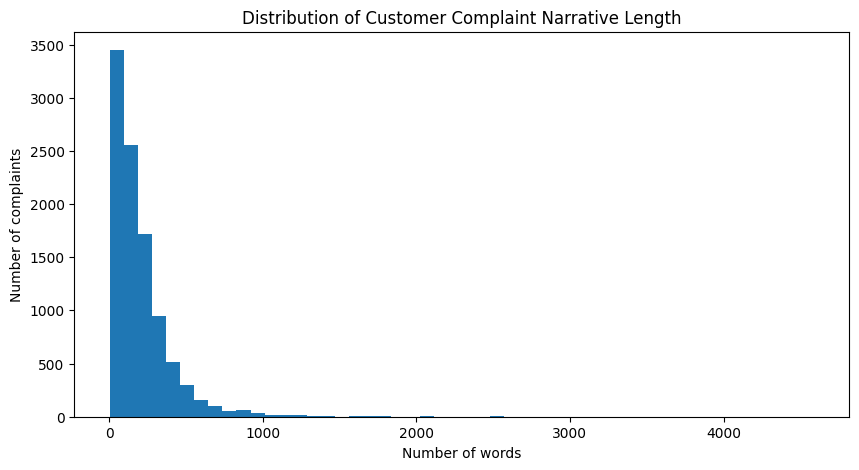

In [70]:
plt.figure(figsize=(10, 5))

plt.hist(
    df["narrative_length"],
    bins=50
)

plt.xlabel("Number of words")
plt.ylabel("Number of complaints")
plt.title("Distribution of Customer Complaint Narrative Length")

plt.show()

##### Narrative Length Finding

The 10,000 complaint narratives vary considerably in length.

The median narrative contains 147 words, while the mean is approximately 207 words. The difference between the two is influenced by a relatively small number of much longer narratives.

Most complaints fall within a relatively short-to-medium length range, while very long narratives are uncommon. The longest narrative in the working dataset contains 4,590 words.

This suggests that most customer complaints provide a manageable amount of text for analysis, while unusually long narratives may need to be considered separately during later text processing.

In [73]:
short_narratives = (
    df[
        [
            "complaint_id",
            "issue",
            "sub_issue",
            "narrative_length",
            "complaint_what_happened"
        ]
    ]
    .sort_values("narrative_length")
    .head(20)
)

short_narratives

,complaint_id,issue,sub_issue,narrative_length,complaint_what_happened
9489,9030620,Problem with a company's investigation into an existing problem,Was not notified of investigation status or results,4,See the attached documents.
8649,9092145,Problem with a company's investigation into an existing problem,Was not notified of investigation status or results,4,See the attached documents
4432,9499444,Problem with a company's investigation into an existing problem,Was not notified of investigation status or results,4,See the attached documents
9056,9061316,Problem with a company's investigation into an existing problem,Was not notified of investigation status or results,4,See the attached documents.
6904,9244598,Problem with a company's investigation into an existing problem,Was not notified of investigation status or results,4,See the attached documents.
8473,9104246,"Other features, terms, or problems",Other problem,5,these is not my accounts
8911,9071971,Getting a credit card,Card opened without my consent or knowledge,5,amount {$530.00} opened on XX/XX/year>
6888,9246865,Credit monitoring or identity theft protection services,Problem canceling credit monitoring or identify theft protection service,5,Discover bank account is fraudulent
5918,9341716,Getting a credit card,Application denied,5,Fraudulent accounts please remove thanks
9922,8999535,Problem with a purchase shown on your statement,Credit card company isn't resolving a dispute about a purchase on your statement,5,Unauthorized access to my account


##### Narrative Quality Finding

The narrative-length analysis showed that short narratives are not necessarily unusable.

Some very short complaints still communicate a clear customer problem, such as an unauthorized account or fraudulent activity.

However, some records contain text such as "See the attached documents." These records technically have a narrative but do not provide useful information in the narrative field itself.

Therefore, I will not remove complaints simply because they are short. Instead, I will identify narratives that contain insufficient text for the later text analysis and handle them separately.

In [74]:
attachment_only = (
    df["complaint_what_happened"]
    .str.strip()
    .str.lower()
    .isin([
        "see the attached documents.",
        "see the attached documents"
    ])
)

print("Attachment-only narratives:", attachment_only.sum())
print(
    "Percentage of dataset:",
    round(attachment_only.mean() * 100, 2),
    "%"
)

Attachment-only narratives: 5
Percentage of dataset: 0.05 %


In [ ]:
## The proportion of genuinely very short narratives

for threshold in [10, 20, 50]:
    count = (df["narrative_length"] < threshold).sum()
    percentage = count / len(df) * 100

    print(
        f"Fewer than {threshold} words: "
        f"{count:,} complaints ({percentage:.2f}%)"
    )

Fewer than 10 words: 40 complaints (0.40%)
Fewer than 20 words: 246 complaints (2.46%)
Fewer than 50 words: 1,650 complaints (16.50%)


##### Narrative Quality Decision

Only 5 records (0.05%) contain an attachment-only message rather than a meaningful narrative.

Although 16.50% of the narratives contain fewer than 50 words, manual inspection showed that short narratives can still communicate a clear customer problem.

I will therefore keep short narratives in the dataset rather than applying an arbitrary word-count cutoff.

The small number of attachment-only narratives will be excluded only when performing analyses that require meaningful narrative text. The original records will remain in the raw dataset.

##### Creating the Text Analysis Dataset

The raw dataset will remain unchanged.

For text analysis, I will create a separate working DataFrame and exclude only records whose narrative consists of the attachment-only message identified above.

No word-count threshold will be used.

In [76]:
text_df = df.loc[~attachment_only].copy()

print("Original records:", len(df))
print("Text-analysis records:", len(text_df))
print("Records excluded:", len(df) - len(text_df))

Original records: 10000
Text-analysis records: 9995
Records excluded: 5


In [77]:
print(
    "Empty/attachment-only narratives remaining:",
    text_df["complaint_what_happened"]
    .fillna("")
    .str.strip()
    .str.lower()
    .isin([
        "",
        "see the attached documents.",
        "see the attached documents"
    ])
    .sum()
)

Empty/attachment-only narratives remaining: 0


#### 17. Basic Customer Language

Before using AI or more advanced text analysis, I will use simple word and phrase frequencies as a baseline.

The purpose is to understand the language customers use and identify whether simple text frequency provides useful product insight.

In [ ]:
# combine the narratives, 
# remove common English stopwords and 
# count word frequency

from collections import Counter
import re

stop_words = {
    "the", "and", "was", "to", "of", "a", "in", "for", "on",
    "that", "my", "this", "with", "i", "is", "it", "me",
    "but", "have", "had", "be", "as", "at", "or", "so",
    "from", "not", "they", "we", "are", "were", "has",
    "an", "by", "would", "can", "there", "their", "about",
    "which", "been", "if", "when", "also", "do", "did",
    "our", "you", "your", "he", "she", "his", "her"
}

word_counts = Counter()

for text in text_df["complaint_what_happened"]:
    words = re.findall(r"\b[a-zA-Z]+\b", text.lower())
    
    words = [
        word for word in words
        if word not in stop_words
        and not re.fullmatch(r"x{2,}", word)
    ]
    
    word_counts.update(words)

word_counts.most_common(30)

[('credit', 21541),
 ('card', 18795),
 ('account', 16995),
 ('payment', 7932),
 ('bank', 7766),
 ('no', 6637),
 ('them', 6179),
 ('any', 6130),
 ('year', 5481),
 ('received', 5425),
 ('am', 5258),
 ('information', 5202),
 ('all', 5202),
 ('one', 5195),
 ('told', 5053),
 ('called', 5016),
 ('balance', 4859),
 ('time', 4814),
 ('made', 4470),
 ('s', 4304),
 ('t', 4265),
 ('charge', 4241),
 ('never', 4215),
 ('interest', 4172),
 ('dispute', 4129),
 ('company', 4127),
 ('late', 4084),
 ('because', 4070),
 ('after', 4063),
 ('charges', 3958)]

##### Basic Word Frequency Finding

Simple word frequency provides useful context but does not clearly distinguish customer problems.

Frequent terms are dominated by general credit-card language rather than specific experiences. 

This suggests that individual word frequency is useful for understanding the dataset at a basic level, but it is not sufficient for identifying meaningful customer problems.

#### 18. Exploring Common Phrases

Individual word frequency does not provide enough context to identify customer problems.

I will therefore examine common two-word phrases in the narratives.

This is still a simple non-AI baseline and will help determine whether combining words provides more useful information than looking at individual words.

In [86]:
bigram_counts = Counter()

for text in text_df["complaint_what_happened"]:
    words = re.findall(r"\b[a-zA-Z]+\b", text.lower())
    
    words = [
        word for word in words
        if word not in stop_words
        and not re.fullmatch(r"x{2,}", word)
    ]
    
    bigram_counts.update(zip(words, words[1:]))

[
    (" ".join(phrase), count)
    for phrase, count in bigram_counts.most_common(30)
]

[('credit card', 8455),
 ('capital one', 2521),
 ('customer service', 1809),
 ('credit report', 1649),
 ('american express', 1473),
 ('bank america', 1116),
 ('wells fargo', 1092),
 ('didn t', 977),
 ('don t', 972),
 ('credit score', 951),
 ('synchrony bank', 923),
 ('late fee', 921),
 ('late payment', 843),
 ('card account', 836),
 ('credit cards', 831),
 ('credit limit', 805),
 ('u s', 772),
 ('card company', 728),
 ('late fees', 726),
 ('account closed', 691),
 ('closed account', 638),
 ('never received', 626),
 ('identity theft', 619),
 ('even though', 611),
 ('more than', 590),
 ('credit reporting', 587),
 ('close account', 573),
 ('due date', 548),
 ('phone number', 537),
 ('account number', 520)]

#### Finding — Simple Text Frequency Has Limited Product Insight

Common phrases provide more context than individual word frequencies. Phrases such as "late fee", "late payment", "account closed", "never received", "identity theft", and "credit limit" point toward more specific customer situations.

However, phrase frequency alone cannot tell whether these phrases represent distinct customer problems or occur in several different contexts.

I will therefore use simple frequency analysis as the baseline rather than as the method for identifying the final product opportunities.

#### 19. Customer Language Within Complaint Categories

The CFPB provides issue and sub-issue classifications for the complaints.

I will compare common customer language within major issue categories to see whether broad categories contain different types of customer experiences.

In [87]:
top_issues = df["issue"].value_counts().head(5).index

for issue in top_issues:
    words = []
    
    for text in text_df.loc[text_df["issue"] == issue, "complaint_what_happened"]:
        words.extend(
            word for word in re.findall(r"\b[a-zA-Z]+\b", text.lower())
            if word not in stop_words
            and not re.fullmatch(r"x{2,}", word)
        )
    
    print("\n" + "=" * 80)
    print(issue)
    print(Counter(words).most_common(10))


Problem with a purchase shown on your statement
[('card', 5589), ('credit', 4459), ('dispute', 3180), ('account', 2909), ('charge', 2481), ('charges', 2455), ('no', 2164), ('bank', 2128), ('them', 2109), ('received', 1912)]

Getting a credit card
[('credit', 3777), ('card', 2309), ('account', 1774), ('report', 926), ('information', 889), ('bank', 878), ('any', 763), ('application', 681), ('received', 646), ('number', 604)]

Fees or interest
[('interest', 2201), ('account', 2020), ('card', 1979), ('credit', 1824), ('payment', 1756), ('fee', 1510), ('late', 1458), ('balance', 1456), ('charged', 1055), ('fees', 1048)]

Other features, terms, or problems
[('credit', 2975), ('card', 2663), ('account', 2382), ('bank', 1046), ('any', 999), ('no', 946), ('all', 911), ('balance', 869), ('them', 818), ('one', 814)]

Closing your account
[('account', 2705), ('credit', 2106), ('card', 1611), ('closed', 1062), ('bank', 678), ('payment', 604), ('no', 604), ('one', 585), ('accounts', 541), ('all', 5

##### Finding — Language Varies Across Issues

The most common customer language differs across the major issue categories.

For example, purchase-related complaints are strongly associated with terms such as "dispute" and "charge", while fees and interest complaints contain terms such as "interest", "fee", and "late".

At the same time, broad terms such as "credit", "card", and "account" appear across multiple categories.

This suggests that the existing issue categories capture meaningful differences, but they may still contain more specific customer problems that are better examined at the sub-issue and narrative level.

##### 20. Exploring Problems Within a Major Issue

The largest issue category contains several different sub-issues.

I will examine these sub-issues to understand whether a single broad issue category represents distinct customer experiences.

In [88]:
purchase_df = df[
    df["issue"] == "Problem with a purchase shown on your statement"
]

purchase_df["sub_issue"].value_counts()

sub_issue
Credit card company isn't resolving a dispute about a purchase on your statement    1740
Card was charged for something you did not purchase with the card                    623
Overcharged for something you did purchase with the card                              73
Name: count, dtype: int64

##### Finding — Broad Categories Contain Distinct Problems

The largest issue category, "Problem with a purchase shown on your statement", contains three different sub-issues in the working dataset.

The majority concern unresolved purchase disputes, while a substantial group concerns unauthorized charges and a smaller group concerns overcharging.

This confirms that issue-level counts alone are too broad for identifying specific customer problems. The existing sub-issues provide more detail, but the customer narratives may still reveal patterns within these categories.

##### 21. Simple Text-Similarity Baseline

The existing CFPB categories provide one way of grouping complaints. I will now create a simple text-based baseline to compare complaints using the language customers actually use.

TF-IDF will represent each narrative based on the importance of its words within the dataset.

This baseline will later give us something to compare against an AI-based approach.

In [89]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=5
)

tfidf_matrix = vectorizer.fit_transform(
    text_df["complaint_what_happened"]
)

print("Documents:", tfidf_matrix.shape[0])
print("Text features:", tfidf_matrix.shape[1])

Documents: 9995
Text features: 5000


In [90]:
print("TF-IDF matrix shape:", tfidf_matrix.shape)

TF-IDF matrix shape: (9995, 5000)


In [91]:
feature_names = vectorizer.get_feature_names_out()

print("Example features:")
print(feature_names[:30])

Example features:
['00' '00 00' '00 account' '00 added' '00 annual' '00 applied' '00 asked'
 '00 available' '00 balance' '00 bank' '00 called' '00 capital' '00 card'
 '00 cash' '00 charge' '00 charged' '00 charges' '00 contacted'
 '00 credit' '00 date' '00 did' '00 disputed' '00 dollars' '00 fee'
 '00 fees' '00 immediately' '00 inaccurately' '00 just' '00 late'
 '00 limit']


##### Finding — TF-IDF Baseline

TF-IDF successfully represented the 9,995 usable complaint narratives using 5,000 text features, including individual words and two-word phrases.

The representation captures differences in customer language, but it does not directly identify or name customer problems. It therefore provides a useful comparison point for the AI-based analysis that follows.